In [5]:
# 라이브러리 준비
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# 시각화 동작 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 학습 리소스 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 디바이스:", device)

사용 디바이스: cpu


In [6]:
# 데이터셋, 데이터로더 준비

# 훈련용 증강 파이프라인
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),          # 좌우 반전
    transforms.RandomVerticalFlip(p=0.1),            # 상하 반전 (선택)
    transforms.RandomRotation(degrees=15),           # ±15도 회전
    transforms.RandomCrop(32, padding=4),            # 랜덤 크롭
    transforms.ColorJitter(
        brightness=0.2, contrast=0.2,
        saturation=0.2, hue=0.1),                    # 색상 변형
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.4914, 0.4822, 0.4465),
                         std=(0.2470, 0.2435, 0.2616)),
    transforms.RandomErasing(p=0.2),                 # 랜덤 영역 삭제
])

# 검증/테스트용 — 증강 없이 정규화만
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.4914, 0.4822, 0.4465),
                         std=(0.2470, 0.2435, 0.2616)),
])

train_dataset_aug = torchvision.datasets.CIFAR10(
    root="./data", train=True,  download=False, transform=train_transform)
test_dataset_aug  = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=False, transform=test_transform)

train_loader_aug = DataLoader(train_dataset_aug, batch_size=64, shuffle=True,  num_workers=2)
test_loader_aug  = DataLoader(test_dataset_aug,  batch_size=64, shuffle=False, num_workers=2)


CLASSES = ["비행기","자동차","새","고양이","사슴",
           "개","개구리","말","배","트럭"]

print(f"훈련 샘플: {len(train_dataset_aug):,} | 테스트 샘플: {len(test_dataset_aug):,}")
print(f"훈련 배치 수: {len(train_loader_aug)}")

훈련 샘플: 50,000 | 테스트 샘플: 10,000
훈련 배치 수: 782


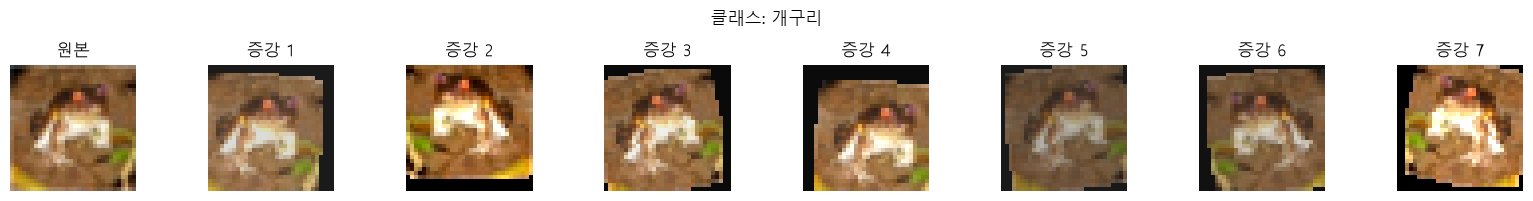

In [7]:
# 증강 결과 시각화 (같은 이미지에 여러 번 증강 적용)
original_img, label = train_dataset_aug[0]

vis_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
])

# 정규화 전 원본 이미지
raw_img = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=False,
    transform=transforms.ToTensor())[0][0]

fig, axes = plt.subplots(1, 8, figsize=(16, 2))
axes[0].imshow(raw_img.permute(1,2,0))
axes[0].set_title("원본")
axes[0].axis("off")

for i in range(1, 8):
    aug = vis_transform(raw_img)
    axes[i].imshow(aug.permute(1,2,0).clamp(0,1))
    axes[i].set_title(f"증강 {i}")
    axes[i].axis("off")

plt.suptitle(f"클래스: {CLASSES[label]}")
plt.tight_layout()
plt.show()


In [11]:
# 모델 설계
import torchvision.models as models

# EfficientNet-B0 로딩
backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# 전체 동결 후 선택적 해제
for param in backbone.parameters():
    param.requires_grad = False

# 마지막 2개 블록 + 분류층만 해제
for param in backbone.features[-2:].parameters():
    param.requires_grad = True

# 분류층 교체
in_features = backbone.classifier[1].in_features
backbone.classifier[1] = nn.Linear(in_features, 10)

model_ft = backbone.to(device)

print(f"Fine-Tuning 학습 파라미터: {sum(p.numel() for p in model_ft.parameters() if p.requires_grad):,}")


7.3%

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\human/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100.0%


Fine-Tuning 학습 파라미터: 1,142,202


In [12]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for X, y in loader:
        X, y = X.to(device), y.to(device)
        pred = model(X)
        loss = criterion(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct    += (pred.argmax(1) == y).sum().item()
        total      += y.size(0)

    return total_loss / len(loader), correct / total


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            pred  = model(X)
            total_loss += criterion(pred, y).item()
            correct    += (pred.argmax(1) == y).sum().item()
            total      += y.size(0)

    return total_loss / len(loader), correct / total


In [13]:
# 학습(훈련) 설계
# 훈련 (동일한 train_epoch / eval_epoch 함수 재사용)
EPOCHS_TL = 10
criterion_tl = nn.CrossEntropyLoss()
# Fine-Tuning 시 학습률 차등 적용
optimizer_ft = torch.optim.Adam([
    {"params": backbone.features[-2:].parameters(), "lr": 1e-4},  # 낮은 학습률
    {"params": backbone.classifier.parameters(),    "lr": 1e-3},  # 높은 학습률
])

# scheduler_tl = torch.optim.lr_scheduler.StepLR(optimizer_ft, step_size=5, gamma=0.1)
# CosineAnnealingLR: 학습률을 코사인 곡선으로 감소
scheduler_cos = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_ft, T_max=50, eta_min=1e-6)

# ReduceLROnPlateau: 검증 손실 개선 없으면 학습률 감소
scheduler_plateau = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_ft, mode="min", factor=0.5, patience=5)

In [14]:
# 학습(훈련) 실행
best_tl_acc = 0.0
for epoch in range(1, EPOCHS_TL + 1):
    tr_loss, tr_acc = train_epoch(model_ft, train_loader_aug, criterion_tl, optimizer_ft, device)
    va_loss, va_acc = eval_epoch(model_ft, test_loader_aug,  criterion_tl, device)
    scheduler_plateau.step()

    if va_acc > best_tl_acc:
        best_tl_acc = va_acc
        torch.save(model_ft.state_dict(), "efficientnet_best.pt")

    print(f"Epoch {epoch:>2} | Train {tr_acc:.2%} | Val {va_acc:.2%}")

print(f"\n최고 정확도 (EfficientNet Fine-Tuning): {best_tl_acc:.2%}")

KeyboardInterrupt: 